# SentinelHub tutorial

This is a small tutorial I wrote to myself about how to use sentinel satellite data from SentinelHub.

A few points to understand:

- Sentinel satellite data are available, mostly for free, directly from Copernicus; this includes in particular the Sentinel satellite products
- However, it seems like private companies are contracted to do some of the development work; these companies may write documentation that pushes towards using their (not always free) data servers - be aware of this when reading doc and following tutorials!
- For example, the sentinelhub python package pushes in the documentation towards some private company servers, though the same data are available fully for free from Copernicus

# Setting up your account

- go to the Copernicus "CDSE" (Copernicus Data Space Ecosystem) website and register: https://dataspace.copernicus.eu/
- set up 2FA on your account
- generate a OAuth client in your dashboard: on the top right, expand on your name, and go to settings; see more at: https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html
- documentation is largely gathered at https://documentation.dataspace.copernicus.eu/Home.html

You should be ready to go!

# Using their data

In [10]:
# a few imports first, that we will use in the whole following

import subprocess

from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    DownloadRequest,
    MimeType,
    MosaickingOrder,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
    bbox_to_resolution,
)

import datetime

from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
import requests

import json

import geopandas as gpd
from shapely.geometry import box, Polygon, LineString

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.plot import show
import rioxarray

import numpy as np

In [2]:
# load the id and secret from the OAuth client - these should be stored safely
# I store my credentials in pass the standard unix password manager: https://www.passwordstore.org/ ; if you use something else, adapt
# do not store credentials in plain text anywhere!
credential_date = "2025-05-19"  # how I name my credentials in my pass entry; note that credentials may expire
client_id_cmd_res = subprocess.run(f"pass show Copernicus_CDSE/OAuthClient/{credential_date}_client_id", shell=True, capture_output=True, text=True)
client_secret_cmd_res = subprocess.run(f"pass show Copernicus_CDSE/OAuthClient/{credential_date}_client_secret", shell=True, capture_output=True, text=True)

client_id = client_id_cmd_res.stdout[:-1]
client_secret = client_secret_cmd_res.stdout[:-1]

# create the oauth session to retrieve the metadata
client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)


def sentinelhub_compliance_hook(response):
    response.raise_for_status()
    return response


oauth.register_compliance_hook("access_token_response", sentinelhub_compliance_hook)

In [3]:
# Get token for the session; note that this expires - if you are slow, may need to ask for a new one
_ = oauth.fetch_token(token_url='https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
                          client_secret=client_secret, include_client_id=True)

# Querying the data index

It is possible to query the data index - only getting metadata

In [4]:
# list available data collections

print("Supported DataCollections:\n")
for collection in DataCollection.get_available_collections():
    print(collection)

Supported DataCollections:

DataCollection.SENTINEL2_L1C
DataCollection.SENTINEL2_L2A
DataCollection.SENTINEL1
DataCollection.SENTINEL1_IW
DataCollection.SENTINEL1_IW_ASC
DataCollection.SENTINEL1_IW_DES
DataCollection.SENTINEL1_EW
DataCollection.SENTINEL1_EW_ASC
DataCollection.SENTINEL1_EW_DES
DataCollection.SENTINEL1_EW_SH
DataCollection.SENTINEL1_EW_SH_ASC
DataCollection.SENTINEL1_EW_SH_DES
DataCollection.DEM
DataCollection.DEM_MAPZEN
DataCollection.DEM_COPERNICUS_30
DataCollection.DEM_COPERNICUS_90
DataCollection.MODIS
DataCollection.LANDSAT_MSS_L1
DataCollection.LANDSAT_TM_L1
DataCollection.LANDSAT_TM_L2
DataCollection.LANDSAT_ETM_L1
DataCollection.LANDSAT_ETM_L2
DataCollection.LANDSAT_OT_L1
DataCollection.LANDSAT_OT_L2
DataCollection.SENTINEL5P
DataCollection.SENTINEL3_OLCI
DataCollection.SENTINEL3_SLSTR
DataCollection.HARMONIZED_LANDSAT_SENTINEL


In [5]:
# prepare a catalog data request within a boundy box for a given time interval

# the bounding box is "lower left lon,lat" followed by "upper right lon, lat"
# i.e. # [min_lon, min_lat, max_lon, max_lat]
# in CRS.WGS84 format
bounding_box = [9.454, 80.4, 12, 80.88]

# the time interval on which to query
datetime_start = datetime.datetime(2024, 4, 21, 0, 0, tzinfo=datetime.timezone.utc)
datetime_end = datetime.datetime(2024, 4, 29, 0, 0, tzinfo=datetime.timezone.utc)

# prepare the request to the catalog for specific data
# for information about the collections that can be queried: https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data.html#listing-Sentinelhub_data-page=1
data_query_params = {
    "bbox": bounding_box,
    "datetime": f"{datetime_start.isoformat(timespec='seconds')}/{datetime_end.isoformat(timespec='seconds')}",
    "collections": ["sentinel-1-grd"],
    "limit": 5,
}

In [6]:
# actually perform the request

url = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"
response = oauth.post(url, json=data_query_params)

if response.status_code == 200:
    response_data = response.json()
else:
    raise RuntimeError(f"got error {response.status_code} on json query:\n {data_query_params}")

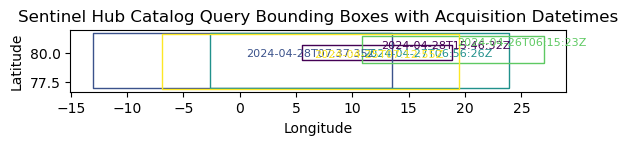

In [7]:
# show visually what we got back

# Extract bounding boxes and acquisition datetimes from the response
geometries = []
acquisition_datetimes = []
for feature in response_data.get('features', []):
    bbox = feature['bbox']
    acquisition_datetime = feature['properties']['datetime']
    # Create a shapely box (rectangle) from the bounding box coordinates
    geom = box(bbox[0], bbox[1], bbox[2], bbox[3])
    geometries.append(geom)
    acquisition_datetimes.append(acquisition_datetime)

# Create a GeoDataFrame from the geometries
gdf = gpd.GeoDataFrame(geometry=geometries)

# Use a colormap to create a gradient
colormap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=len(gdf) - 1)
edge_colors = [colormap(norm(i)) for i in range(len(gdf))]

# Plot the geometries with gradient edge colors
ax = gdf.plot(edgecolor=edge_colors, facecolor='none')  # Set facecolor to 'none' to not fill the boxes

# Annotate each box with its acquisition datetime
for idx, (geom, acq_datetime) in enumerate(zip(gdf.geometry, acquisition_datetimes)):
    # Calculate the center of the bounding box for labeling
    centroid = geom.centroid
    ax.annotate(acq_datetime, xy=(centroid.x, centroid.y), xytext=(3, 3),
                textcoords='offset points', fontsize=8, color=edge_colors[idx])

# TODO: show the user box

plt.title('Sentinel Hub Catalog Query Bounding Boxes with Acquisition Datetimes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [8]:
# let us focus on the first acquisition that matches

features = response_data.get('features', [])
sorted_features = sorted(features, key=lambda f: f['properties']['datetime'])

# Get the first acquisition data
first_acquisition = sorted_features[0]

bbox = first_acquisition['bbox']
feature_id = first_acquisition['id']

print("Bounding Box:", bbox)
print("Feature ID:", feature_id)

for crrt_key in first_acquisition["properties"]:
    print(f"{crrt_key}: {first_acquisition["properties"][crrt_key]}")

Bounding Box: [-6.90142390476512, 76.85033080213998, 19.448819160479843, 81.76344760755224]
Feature ID: S1A_EW_GRDM_1SDH_20240425T071255_20240425T071359_053587_068170_CD19_COG.SAFE
datetime: 2024-04-25T07:12:55Z
platform: sentinel-1a
instruments: ['c-sar']
constellation: sentinel-1
sat:orbit_state: descending
sat:absolute_orbit: 53587
sat:relative_orbit: 140
sar:instrument_mode: EW
sar:frequency_band: C
sar:center_frequency: 5.405
sar:polarizations: ['HH', 'HV']
sar:product_type: GRD
sar:resolution_range: 93.0
sar:resolution_azimuth: 87.0
sar:pixel_spacing_range: 40.0
sar:pixel_spacing_azimuth: 40.0
s1:timeliness: NRT3h
s1:resolution: MEDIUM
s1:polarization: DH


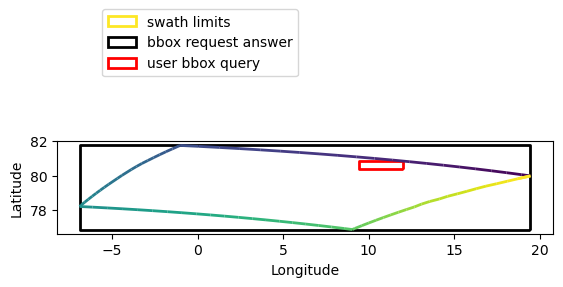

In [9]:
# showing how things look like in space: user location box request, actual query bbox, actual swath

polygon_coordinates = first_acquisition["geometry"]["coordinates"][0]

legend_patch_list = []

lines = []

for point, next_point in zip(polygon_coordinates[0:-1], polygon_coordinates[1:]):
    lines.append(LineString([point, next_point]))

# Create a GeoDataFrame containing the LineStrings
gdf = gpd.GeoDataFrame(geometry=lines)

# Set up the colormap
cmap = cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=len(gdf) - 1)

# Plot the LineStrings with colors based on their index
fig, ax = plt.subplots()
for idx, line in enumerate(gdf.geometry):
    edge_color = cmap(norm(idx))
    gdf_single = gpd.GeoDataFrame(geometry=[line])
    gdf_single.plot(ax=ax, color=edge_color, linewidth=2)  # Plot the line
gdf_single.plot(ax=ax, color=edge_color, linewidth=2, label="swath limits")  # Plot the line
# Create a legend proxy
legend_patch = Patch(facecolor='none', edgecolor=edge_color, linewidth=2, label='swath limits')
legend_patch_list.append(legend_patch)

bbox_coordinates = first_acquisition["bbox"]
polygon = box(*bbox_coordinates)
gdf = gpd.GeoDataFrame(geometry=[polygon])
gdf.plot(ax=ax, edgecolor='black', facecolor='none', label="bbox request answer", linewidth=2)
# Create a legend proxy
legend_patch = Patch(facecolor='none', edgecolor='black', linewidth=2, label='bbox request answer')
legend_patch_list.append(legend_patch)

polygon = box(*bounding_box)
gdf = gpd.GeoDataFrame(geometry=[polygon])
gdf.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
# Create a legend proxy
legend_patch = Patch(facecolor='none', edgecolor='red', linewidth=2, label='user bbox query')
legend_patch_list.append(legend_patch)

ax.legend(handles=legend_patch_list, bbox_to_anchor=(0.5, 2.5))  # Use the proxy artist for legend

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Actually get the satellite data

- Note that it seems to not be possible to use the catalog ID to perform the request: see https://forum.sentinel-hub.com/t/download-via-process-api-using-id-field/3536

In [18]:
# prepare the request for the data

# we need an evalscript, that describes what we want to take out; here I just grab the 2 channels in the first_acquisition: sar:polarizations: ['HH', 'HV']
# together with the data mask (indicating within or outside mask)
# for more information, see: https://docs.sentinel-hub.com/api/latest/evalscript/

# NOTE: for other polarizations and modes, one may need to adapt, for example using the polarizations VH, VV, or only the subset of polarizations used
evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["HH", "HV", "dataMask"],
    output: { bands: 3 }
  };
}

function evaluatePixel(sample) {
  return [sample.HH, sample.HV, sample.dataMask];
}
"""

# you can think in advance about the resolution nbr of pixels etc
desired_resolution_m = 100
pixels = bbox_to_dimensions(BBox(bbox=bounding_box, crs=CRS.WGS84), desired_resolution_m)
print(f"to get a resolution of {desired_resolution_m}m with the bbox {bounding_box}, you need a number of pixels: {pixels}.")

# NOTE: there are many more options for performing the dataFilter ing; google and ask LLMs :)
processing_payload = {
    "input": {
        "bounds": {
            "bbox": bounding_box,
        },
        "data": [
            {
                "type": "sentinel-1-grd",
                "dataFilter": {
                    "timeRange": {
                        "from": (datetime.datetime.fromisoformat(first_acquisition["properties"]["datetime"]) - datetime.timedelta(minutes=1)).isoformat(),
                        "to": (datetime.datetime.fromisoformat(first_acquisition["properties"]["datetime"]) + datetime.timedelta(minutes=1)).isoformat()
                    },
                }
            }
        ]
    },
    "output": {
        # NOTE: the width and height may need to be adapted to the actual available data, to match the max resolution available and the user need
        # see the 
        "width": pixels[0],
        "height": pixels[1],
        "responses": [
            {
                "identifier": "default",
                "format": {
                    "type": "image/tiff",
                    "parameters": {
                        "compression": "DEFLATE"  # Optionally compress the GeoTIFF
                    }
                }
            }
        ]
    },
    "evalscript": evalscript
}

url = "https://sh.dataspace.copernicus.eu/api/v1/process"
response = oauth.post(url, json=processing_payload)

if response.status_code == 200:
    with open('sentinel1_image.tiff', 'wb') as file:
        file.write(response.content)
    print("Sentinel-1 image saved as 'sentinel1_image.tiff'.")
else:
    print(f"Image request failed with status code: {response.status_code}")
    print(response.json())

to get a resolution of 100m with the bbox [9.454, 80.4, 12, 80.88], you need a number of pixels: (500, 500).
Sentinel-1 image saved as 'sentinel1_image.tiff'.


/tmp/ipykernel_798788/3530825470.py:19: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(c, ax=ax, label="HH return")
/tmp/ipykernel_798788/3530825470.py:23: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(c, ax=ax, label="HV return")


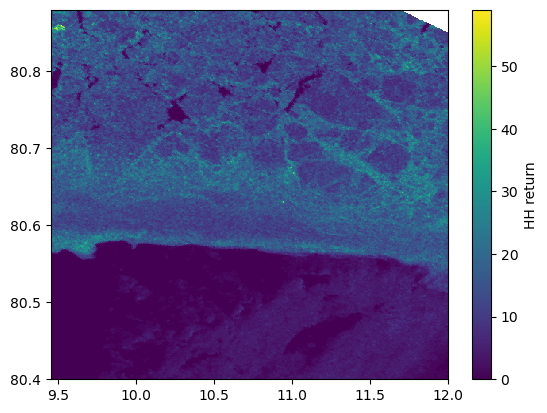

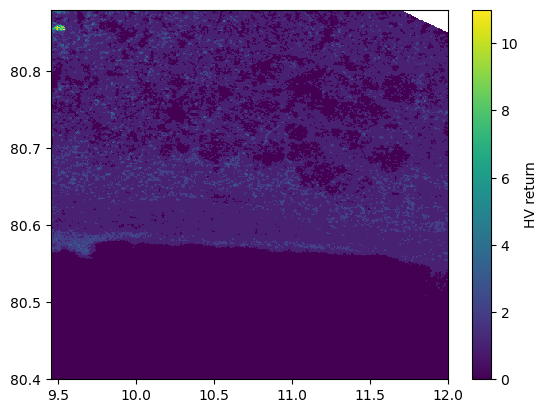

In [19]:
# load with xarray

# Path to the GeoTIFF file
geotiff_path = 'sentinel1_image.tiff'

# Load the GeoTIFF into an xarray DataArray using rioxarray
data_array = rioxarray.open_rasterio(geotiff_path)

# make a float version where replace 0s with NaN: out of the swath
where_zeros = data_array.data[2, :, :] == 0
data_as_float = data_array.data.astype('float16')
data_as_float[0, where_zeros] = np.nan
data_as_float[1, where_zeros] = np.nan

# plot

fig, ax = plt.subplots()
c = ax.pcolor(data_array.x, data_array.y, data_as_float[0, :, :])
plt.colorbar(c, ax=ax, label="HH return")

fig, ax = plt.subplots()
c = ax.pcolor(data_array.x, data_array.y, data_as_float[1, :, :])
plt.colorbar(c, ax=ax, label="HV return")

plt.show()

# Going further

Quite a bit more can be done both on the querying and the data analysis.

For example, there are different algorithms for combining the channels into a single image.

For possible inspiration, see for example the way OVL does it:

- download the zip of the idf-converter Python package https://pypi.org/project/idf-converter/#idf_converter-0.1.426.tar.gz or newer version
- notable pieces of code (pointer credit OVL and S.H.):
  - The _compute_roughness method defined at line 215 of idf_converter/lib/sar.py computes roughness based on sigma0 and incidence angle, using different gmf depending on polarization.
  - The min/max selection in the "if" block starting line 397 of idf_converter/readers/sentinel1_l1.py (note that in OVL we use the "sea" contrast, see lines 423-437)
  - The application of the LUT on sigma0 in lines 644-651 of idf_converter/readers/sentinel1_l1.py

See also papers, examples on sentinelhub, etc.